<a href="https://colab.research.google.com/github/Rajeshpatra12/Rajeshpatra12/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Importing Dataset

In [28]:
# Step 2: Load Dataset (download CSV from Kaggle)
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Tweets.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (14640, 3)


## Data preparation

### Subtask:
Reset the index of the dataframe to include the 'tweet_created' column again.


**Reasoning**:
Resetting the index of the `data` DataFrame will convert the 'tweet_created' index back into a regular column, which is necessary for subsequent steps that might not rely on a time-based index.



In [27]:
print(data[['text','airline_sentiment']].head())

                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative


In [30]:
data

,index,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [31]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

https://docs.google.com/spreadsheets/d/17ar7bvrfiFvACEw7NQCwSoa6xp3nV9Z3HXvd5Mtkb6s/edit#gid=0


In [29]:
data.reset_index(inplace=True)
display(data.head())

,index,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Group by airline and sentiment

### Subtask:
Group the data by 'airline' and 'airline_sentiment' and count the occurrences.


**Reasoning**:
Group the data by 'airline' and 'airline_sentiment' and count the occurrences.



In [ ]:
airline_sentiment_counts = data.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
display(airline_sentiment_counts.head())

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492


In [12]:
# Step 3: Keep only required columns
df = df[['text','airline_sentiment']]

In [13]:
# Step 4: Encode labels
sentiment_mapping = {"negative":0, "neutral":1, "positive":2}
df['label'] = df['airline_sentiment'].map(sentiment_mapping)

In [14]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [15]:
# Step 6: Text Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [16]:
# Step 7: Train Logistic Regression Model
model = LogisticRegression(max_iter=300)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=300)

In [17]:
# Step 8: Predictions
y_pred = model.predict(X_test_vec)

In [18]:
# Step 9: Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=['Negative','Neutral','Positive']
))

✅ Accuracy: 0.7957650273224044

Classification Report:
               precision    recall  f1-score   support

    Negative       0.83      0.93      0.87      1889
     Neutral       0.65      0.49      0.56       580
    Positive       0.79      0.63      0.70       459

    accuracy                           0.80      2928
   macro avg       0.76      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



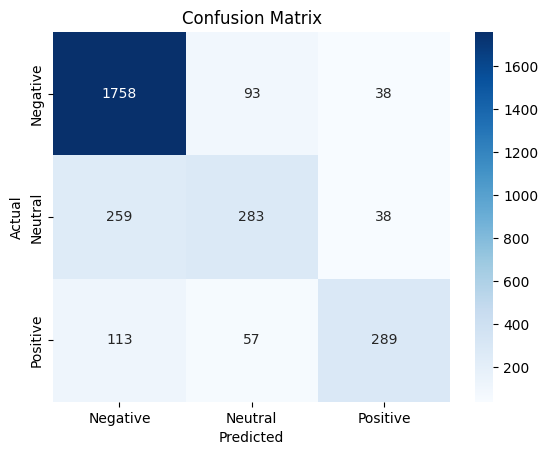

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Step 10: Test Custom Tweets
sample_tweets = [
    "I love the friendly service of this airline!",
    "The flight was delayed for 3 hours. Terrible experience.",
    "It was an okay flight, nothing special."
]
sample_vec = vectorizer.transform(sample_tweets)
preds = model.predict(sample_vec)

for tweet, pred in zip(sample_tweets, preds):
    sentiment = ["Negative","Neutral","Positive"][pred]
    print(f"Tweet: {tweet} --> Sentiment: {sentiment}")

Tweet: I love the friendly service of this airline! --> Sentiment: Positive
Tweet: The flight was delayed for 3 hours. Terrible experience. --> Sentiment: Negative
Tweet: It was an okay flight, nothing special. --> Sentiment: Negative



Visualize the distribution of airline sentiment for each airline using a bar plot.

## Visualize sentiment distribution

### Subtask:
Create a bar plot to visualize the sentiment distribution for each airline.


**Reasoning**:
Create a bar plot to visualize the sentiment distribution for each airline using the pre-calculated `airline_sentiment_counts` DataFrame.



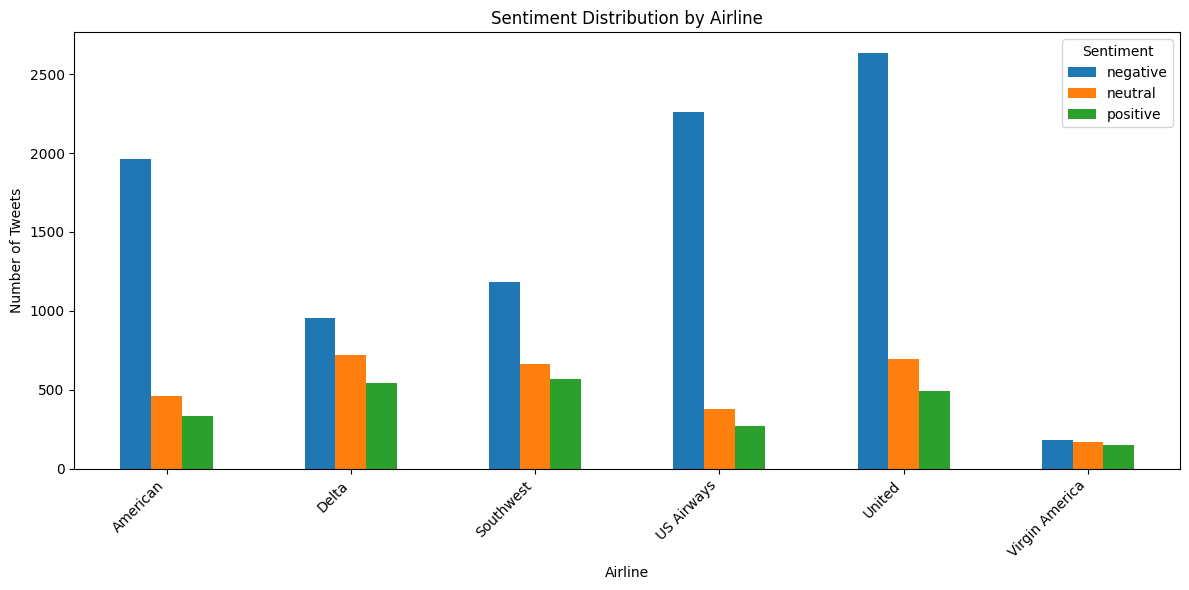

In [25]:
plt.figure(figsize=(12, 6))
airline_sentiment_counts.plot(kind='bar', ax=plt.gca())
plt.title('Sentiment Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

* The sentiment distribution for each airline was visualized using a bar plot.
* For all airlines, the number of negative tweets is significantly higher than the number of neutral or positive tweets.
* United Airlines appears to have the highest number of negative tweets, followed by US Airways.
* Virgin America shows the lowest number of negative tweets among the airlines.
* The number of neutral and positive tweets is relatively low for all airlines compared to negative tweets.

### Insights or Next Steps

* Further analysis could investigate the specific reasons behind the high volume of negative sentiment for airlines, potentially by analyzing the content of the negative tweets.
* Airlines could use these findings to prioritize areas for improvement based on the sentiment analysis.
